In [1]:
# Mount Drive & Load Data

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pickle

SAVE_PATH = '/content/drive/MyDrive/FaceAttendance/data'

X_train = np.load(f'{SAVE_PATH}/X_face_train.npy')
X_test  = np.load(f'{SAVE_PATH}/X_face_test.npy')
y_train = np.load(f'{SAVE_PATH}/y_face_train.npy')
y_test  = np.load(f'{SAVE_PATH}/y_face_test.npy')

with open(f'{SAVE_PATH}/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print(f'Data loaded!')
print(f'   Train: {X_train.shape} | Test: {X_test.shape}')
print(f'   Classes: {len(le.classes_)}')

Mounted at /content/drive
Data loaded!
   Train: (2600, 224, 224, 3) | Test: (650, 224, 224, 3)
   Classes: 67


In [2]:

# CELL 2 — Build Face Recognition Model (MobileNetV2)

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = len(le.classes_)

# Load pretrained MobileNetV2 (no top layer)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                          include_top=False,
                          weights='imagenet')

# Freeze base layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f'Model built!')
print(f'   Total params: {model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built!
   Total params: 2,603,139


In [3]:
# CELL 3 — Train Model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/FaceAttendance/models/face_recognition.h5',
                    save_best_only=True, verbose=1)
]

import os
os.makedirs('/content/drive/MyDrive/FaceAttendance/models', exist_ok=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks
)

print(' Training complete!')

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.1977 - loss: 3.7819
Epoch 1: val_loss improved from None to 2.85820, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 56s 445ms/step - accuracy: 0.2542 - loss: 3.4059 - val_accuracy: 0.3523 - val_loss: 2.8582
Epoch 2/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3769 - loss: 2.6542
Epoch 2: val_loss improved from 2.85820 to 2.48089, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 2: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.3946 - loss: 2.5859 - val_accuracy: 0.4185 - val_loss: 2.4809
Epoch 3/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4738 - loss: 2.1498
Epoch 3: val_loss improved from 2.48089 to 2.06461, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 3: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4808 - loss: 2.1090 - val_accuracy: 0.5123 - val_loss: 2.0646
Epoch 4/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5451 - loss: 1.7660
Epoch 4: val_loss improved from 2.06461 to 1.81499, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 4: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.5523 - loss: 1.7322 - val_accuracy: 0.5569 - val_loss: 1.8150
Epoch 5/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6425 - loss: 1.4602
Epoch 5: val_loss improved from 1.81499 to 1.64291, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5


...


Epoch 12: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8542 - loss: 0.5547 - val_accuracy: 0.6969 - val_loss: 1.2826
Epoch 13/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8899 - loss: 0.4837
Epoch 13: val_loss improved from 1.28264 to 1.23888, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 13: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8908 - loss: 0.4764 - val_accuracy: 0.6908 - val_loss: 1.2389
Epoch 14/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8944 - loss: 0.4127
Epoch 14: val_loss did not improve from 1.23888
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8938 - loss: 0.4232 - val_accuracy: 0.6769 - val_loss: 1.3540
Epoch 15/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9140 - loss: 0.3584
Epoch 15: val_loss improved from 1.23888 to 1.23758, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 15: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9115 - loss: 0.3764 - val_accuracy: 0.7000 - val_loss: 1.2376
Epoch 16/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9106 - loss: 0.3566
Epoch 16: val_loss did not improve from 1.23758
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9158 - loss: 0.3378 - val_accuracy: 0.6877 - val_loss: 1.3138
Epoch 17/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9306 - loss: 0.3025
Epoch 17: val_loss improved from 1.23758 to 1.19374, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 17: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9277 - loss: 0.3044 - val_accuracy: 0.7123 - val_loss: 1.1937
Epoch 18/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9443 - loss: 0.2603
Epoch 18: val_loss did not improve from 1.19374
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9423 - loss: 0.2642 - val_accuracy: 0.6938 - val_loss: 1.2568
Epoch 19/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9360 - loss: 0.2528
Epoch 19: val_loss improved from 1.19374 to 1.15783, saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5



Epoch 19: finished saving model to /content/drive/MyDrive/FaceAttendance/models/face_recognition.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9450 - loss: 0.2436 - val_accuracy: 0.7246 - val_loss: 1.1578
Epoch 20/20
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9525 - loss: 0.2129
Epoch 20: val_loss did not improve from 1.15783
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9504 - loss: 0.2152 - val_accuracy: 0.7077 - val_loss: 1.2856
Restoring model weights from the end of the best epoch: 19.
 Training complete!


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7246 - loss: 1.1578
 Test Accuracy: 72.46%


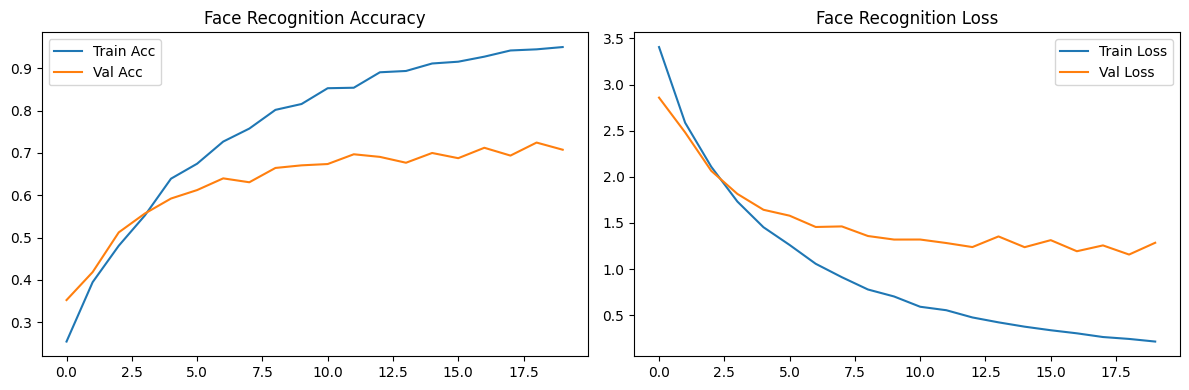

 Plot saved to Drive!


In [4]:

# CELL 4 — Evaluate & Plot

import matplotlib.pyplot as plt

loss, acc = model.evaluate(X_test, y_test)
print(f' Test Accuracy: {acc*100:.2f}%')

# Plot accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Face Recognition Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Face Recognition Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FaceAttendance/face_recognition_plot.png')
plt.show()
print(' Plot saved to Drive!')

In [5]:
import os
files = os.listdir('/content/drive/MyDrive/FaceAttendance/models')
print(files)

['face_recognition.h5', 'attention_classifier.h5']
